In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

BASE_PATH = "/content/drive/MyDrive/KeepCoding/NLP_SEARCHING/practica_final_nlp"
DATA_PATH = os.path.join(BASE_PATH, "data")
OUTPUT_PATH = os.path.join(BASE_PATH, "outputs")

os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Ruta base:", BASE_PATH)
print("Ruta data:", DATA_PATH)
print("Ruta outputs:", OUTPUT_PATH)

Ruta base: /content/drive/MyDrive/KeepCoding/NLP_SEARCHING/practica_final_nlp
Ruta data: /content/drive/MyDrive/KeepCoding/NLP_SEARCHING/practica_final_nlp/data
Ruta outputs: /content/drive/MyDrive/KeepCoding/NLP_SEARCHING/practica_final_nlp/outputs


In [5]:
import pandas as pd

file_path = os.path.join(
    DATA_PATH,
    "musical_instruments_reviews_base.csv"
)

df_reviews = pd.read_csv(file_path)

df_reviews.head()

,reviewText,overall,summary,sentiment
0,"Not much to write about here, but it does exac...",5,good,1
1,The product does exactly as it should and is q...,5,Jake,1
2,The primary job of this device is to block the...,5,It Does The Job Well,1
3,Nice windscreen protects my MXL mic and preven...,5,GOOD WINDSCREEN FOR THE MONEY,1
4,This pop filter is great. It looks and perform...,5,No more pops when I record my vocals.,1


In [7]:
# solo ejecutar la primera vez
#!wget -O "$DATA_PATH/Musical_Instruments_5.json.gz" http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Musical_Instruments_5.json.gz

In [8]:
df = df_reviews
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  10254 non-null  object
 1   overall     10261 non-null  int64 
 2   summary     10261 non-null  object
 3   sentiment   10261 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 320.8+ KB


Index(['reviewText', 'overall', 'summary', 'sentiment'], dtype='object')

In [9]:
df_reviews = df[["reviewText", "overall", "summary"]].copy()

df_reviews.head()

,reviewText,overall,summary
0,"Not much to write about here, but it does exac...",5,good
1,The product does exactly as it should and is q...,5,Jake
2,The primary job of this device is to block the...,5,It Does The Job Well
3,Nice windscreen protects my MXL mic and preven...,5,GOOD WINDSCREEN FOR THE MONEY
4,This pop filter is great. It looks and perform...,5,No more pops when I record my vocals.


In [10]:
#### revisamos valores nulos
df_reviews.isnull().sum()

,0
reviewText,7
overall,0
summary,0


In [11]:
df_reviews["sentiment"] = df_reviews["overall"].apply(lambda x: 1 if x >= 4 else 0)

df_reviews.head()

,reviewText,overall,summary,sentiment
0,"Not much to write about here, but it does exac...",5,good,1
1,The product does exactly as it should and is q...,5,Jake,1
2,The primary job of this device is to block the...,5,It Does The Job Well,1
3,Nice windscreen protects my MXL mic and preven...,5,GOOD WINDSCREEN FOR THE MONEY,1
4,This pop filter is great. It looks and perform...,5,No more pops when I record my vocals.,1


In [12]:
output_file = os.path.join(DATA_PATH, "musical_instruments_reviews_base.csv")

df_reviews.to_csv(output_file, index=False)

print("Archivo guardado en:", output_file)

Archivo guardado en: /content/drive/MyDrive/KeepCoding/NLP_SEARCHING/practica_final_nlp/data/musical_instruments_reviews_base.csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from collections import Counter

sns.set_style("whitegrid")

In [14]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [15]:
df_reviews.shape

(10261, 4)

In [16]:
df_reviews.head()

,reviewText,overall,summary,sentiment
0,"Not much to write about here, but it does exac...",5,good,1
1,The product does exactly as it should and is q...,5,Jake,1
2,The primary job of this device is to block the...,5,It Does The Job Well,1
3,Nice windscreen protects my MXL mic and preven...,5,GOOD WINDSCREEN FOR THE MONEY,1
4,This pop filter is great. It looks and perform...,5,No more pops when I record my vocals.,1


In [17]:
# distribucción de estrellas
df_reviews["overall"].value_counts().sort_index()

,count
overall,
1,217
2,250
3,772
4,2084
5,6938


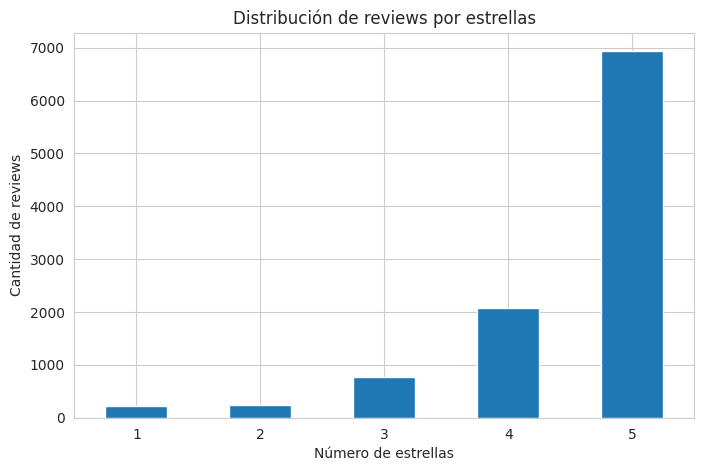

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df_reviews["overall"].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Distribución de reviews por estrellas")
plt.xlabel("Número de estrellas")
plt.ylabel("Cantidad de reviews")

plt.xticks(rotation=0)

plt.show()

In [19]:
# conteo 0 negativas y 1 positivas
df_reviews["sentiment"].value_counts()

,count
sentiment,
1,9022
0,1239


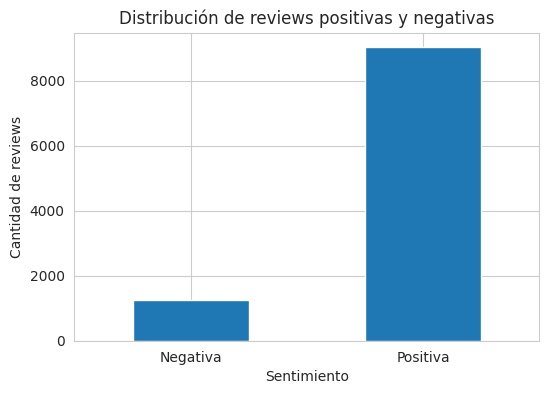

In [20]:
plt.figure(figsize=(6,4))

df_reviews["sentiment"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks(
    ticks=[0, 1],
    labels=["Negativa", "Positiva"],
    rotation=0
)

plt.title("Distribución de reviews positivas y negativas")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reviews")

plt.show()

In [21]:
# porcentaje de reviews positivas y negativas
df_reviews["sentiment"].value_counts(normalize=True).sort_index() * 100

,proportion
sentiment,
0,12.074847
1,87.925153


El dataset tiene muchas más reviews positivas que negativas.

In [22]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [23]:
# Cardinalidad del vocabulario ( palabras únicas )
from nltk.tokenize import word_tokenize

# crear columna de texto completo
df_reviews["text"] = (
    df_reviews["summary"].fillna('') + " " +
    df_reviews["reviewText"].fillna('')
)

all_words = []

for text in df_reviews["text"]:
    tokens = word_tokenize(str(text).lower())
    all_words.extend(tokens)

vocabulario = set(all_words)

print("Número total de palabras:", len(all_words))
print("Cardinalidad del vocabulario:", len(vocabulario))

Número total de palabras: 1110403
Cardinalidad del vocabulario: 31016


Es probable que el vocabulario contenga ruido, signos de puntuación, palabras poco frecuentes y stopwords, aspectos que serán tratados posteriormente en la etapa de preprocesamiento.

In [24]:
# palabras mas frecuentes
from collections import Counter

word_freq = Counter(all_words)

word_freq.most_common(20)

[('.', 48424),
 ('the', 45405),
 (',', 36973),
 ('i', 31584),
 ('a', 28906),
 ('and', 27703),
 ('it', 24885),
 ('to', 23568),
 ('is', 15259),
 ('for', 14569),
 ('of', 13900),
 ('this', 13048),
 ('you', 10421),
 ('that', 9944),
 ('my', 9810),
 ('on', 9363),
 ('with', 9361),
 ('in', 8956),
 ('but', 8338),
 ('have', 7575)]

Se observan palabras mas fecuentes que corresponden a stopwords y signos de puntuación. Entonces requiere de técnicas de preprocesamiento antes del entrenamiento

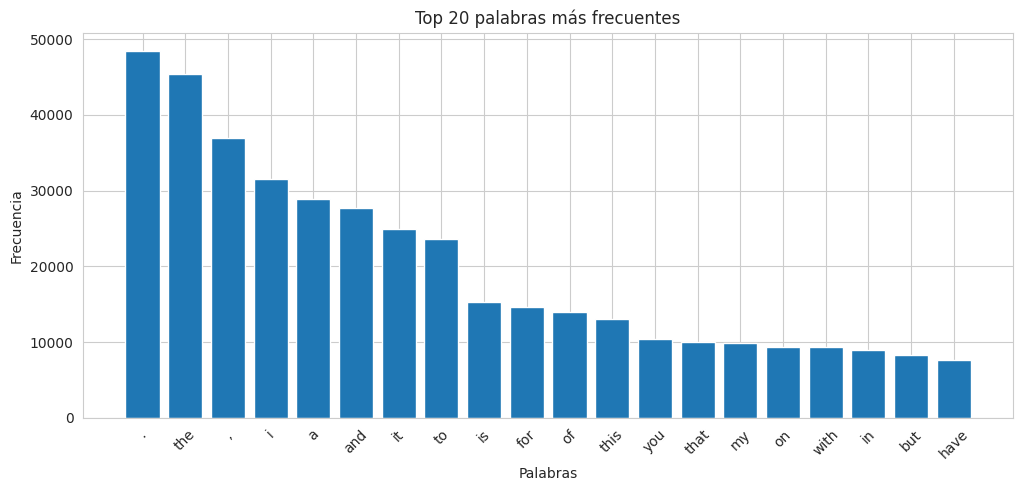

In [25]:
top_words = word_freq.most_common(20)

words = [w[0] for w in top_words]
freqs = [w[1] for w in top_words]

plt.figure(figsize=(12,5))

plt.bar(words, freqs)

plt.xticks(rotation=45)

plt.title("Top 20 palabras más frecuentes")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")

plt.show()

In [26]:
# N-gram
from nltk.util import ngrams
from collections import Counter

In [27]:
bigrams = list(ngrams(all_words, 2))

bigram_freq = Counter(bigrams)

bigram_freq.most_common(20)

[(('.', 'i'), 8941),
 ((',', 'and'), 4718),
 ((',', 'but'), 4160),
 (('.', 'the'), 4038),
 (('.', 'it'), 3868),
 (('it', "'s"), 3596),
 (('of', 'the'), 3198),
 ((',', 'i'), 2912),
 (('i', 'have'), 2834),
 (('on', 'the'), 2451),
 (('if', 'you'), 2312),
 (('for', 'the'), 2282),
 (('it', 'is'), 2259),
 (('is', 'a'), 2247),
 (('this', 'is'), 2076),
 (('do', "n't"), 1985),
 (('in', 'the'), 1866),
 (('i', "'ve"), 1849),
 (('and', 'the'), 1793),
 ((',', 'it'), 1782)]

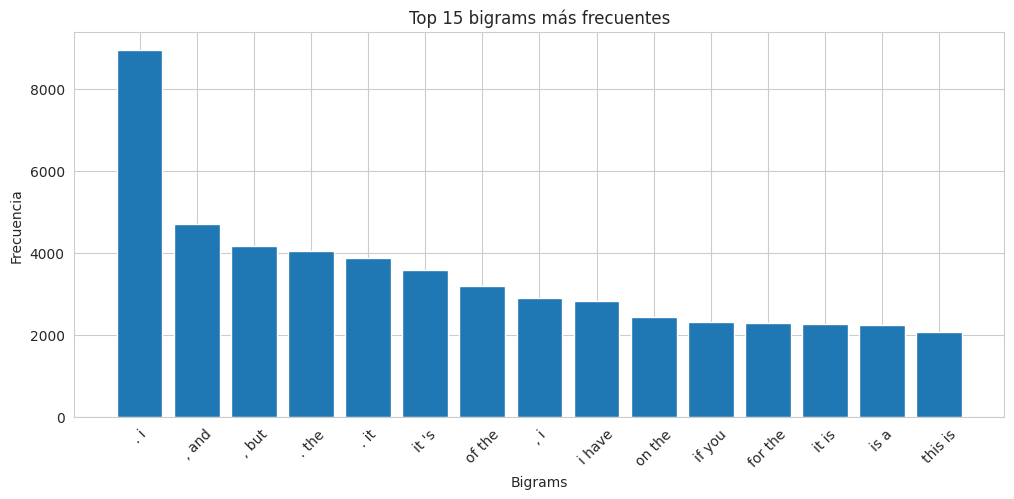

In [28]:
top_bigrams = bigram_freq.most_common(15)

bigram_words = [
    ' '.join(bg[0]) for bg in top_bigrams
]

bigram_counts = [
    bg[1] for bg in top_bigrams
]

plt.figure(figsize=(12,5))

plt.bar(bigram_words, bigram_counts)

plt.xticks(rotation=45)

plt.title("Top 15 bigrams más frecuentes")
plt.xlabel("Bigrams")
plt.ylabel("Frecuencia")

plt.show()

In [29]:
from nltk.corpus import stopwords
import string

In [30]:
stop_words = set(stopwords.words('english'))

clean_words = []

for word in all_words:

    # quitar puntuación
    if word in string.punctuation:
        continue

    # quitar stopwords
    if word in stop_words:
        continue

    # quitar palabras muy cortas
    if len(word) < 3:
        continue

    clean_words.append(word)

In [31]:
# creamos biagrams limpios
clean_bigrams = list(ngrams(clean_words, 2))

clean_bigram_freq = Counter(clean_bigrams)

clean_bigram_freq.most_common(15)

[(('works', 'great'), 520),
 (('works', 'well'), 452),
 (('easy', 'use'), 329),
 (('acoustic', 'guitar'), 323),
 (('well', 'made'), 292),
 (('great', 'price'), 289),
 (('planet', 'waves'), 286),
 (('good', 'quality'), 259),
 (('much', 'better'), 241),
 (('would', "n't"), 240),
 (('would', 'recommend'), 237),
 (('great', 'product'), 235),
 (('sound', 'great'), 234),
 (('electric', 'guitar'), 233),
 (("'ve", 'used'), 233)]

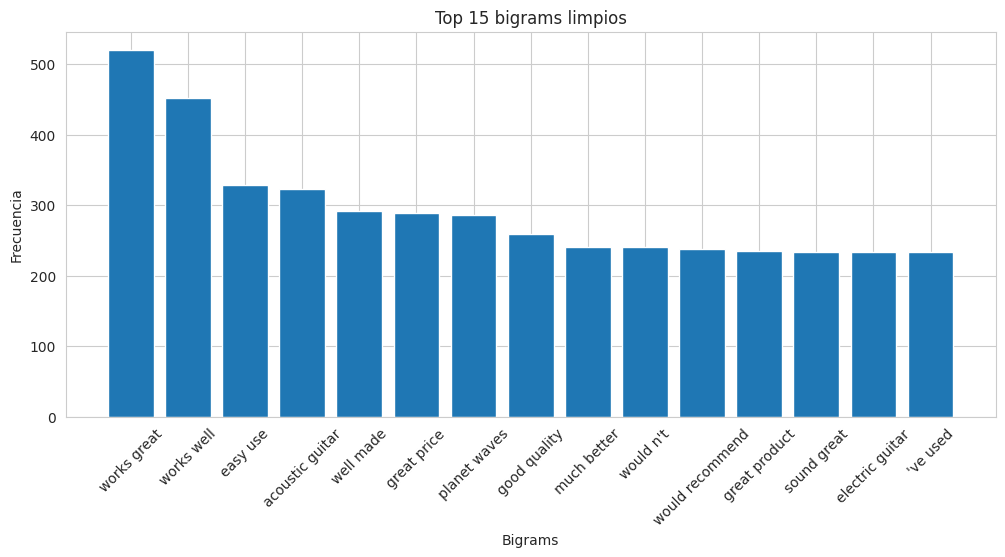

In [32]:
top_clean_bigrams = clean_bigram_freq.most_common(15)

bigram_words = [
    ' '.join(bg[0]) for bg in top_clean_bigrams
]

bigram_counts = [
    bg[1] for bg in top_clean_bigrams
]

plt.figure(figsize=(12,5))

plt.bar(bigram_words, bigram_counts)

plt.xticks(rotation=45)

plt.title("Top 15 bigrams limpios")
plt.xlabel("Bigrams")
plt.ylabel("Frecuencia")

plt.show()

In [33]:
# WordCloud
from wordcloud import WordCloud

In [34]:
clean_text = ' '.join(clean_words)

In [35]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(clean_text)

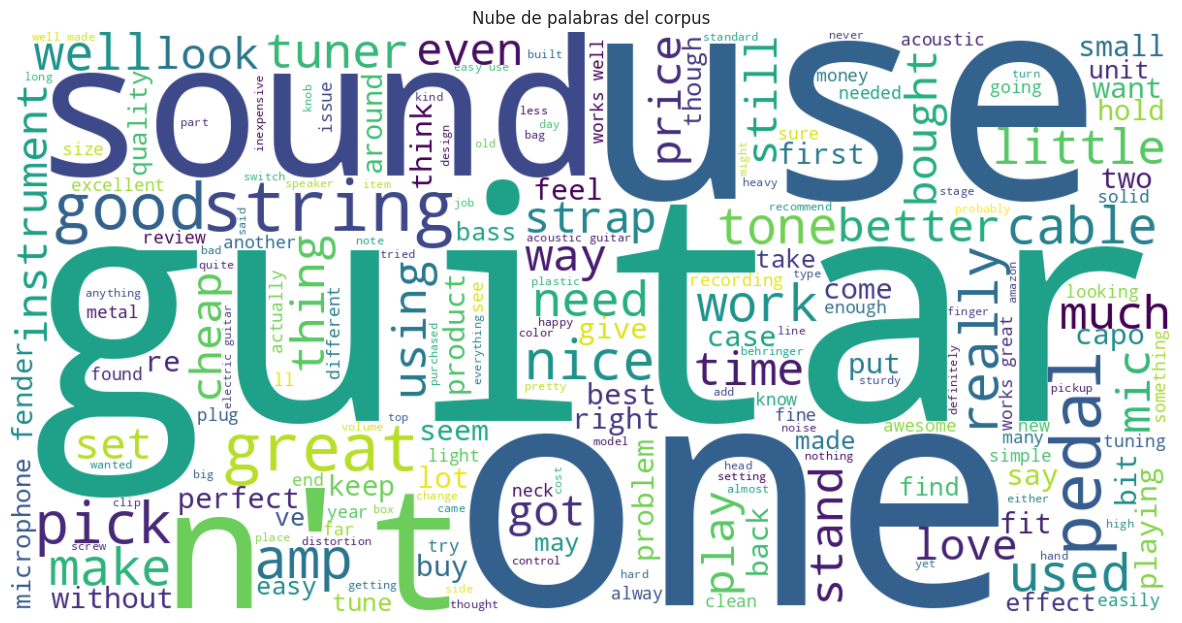

In [36]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Nube de palabras del corpus")

plt.show()

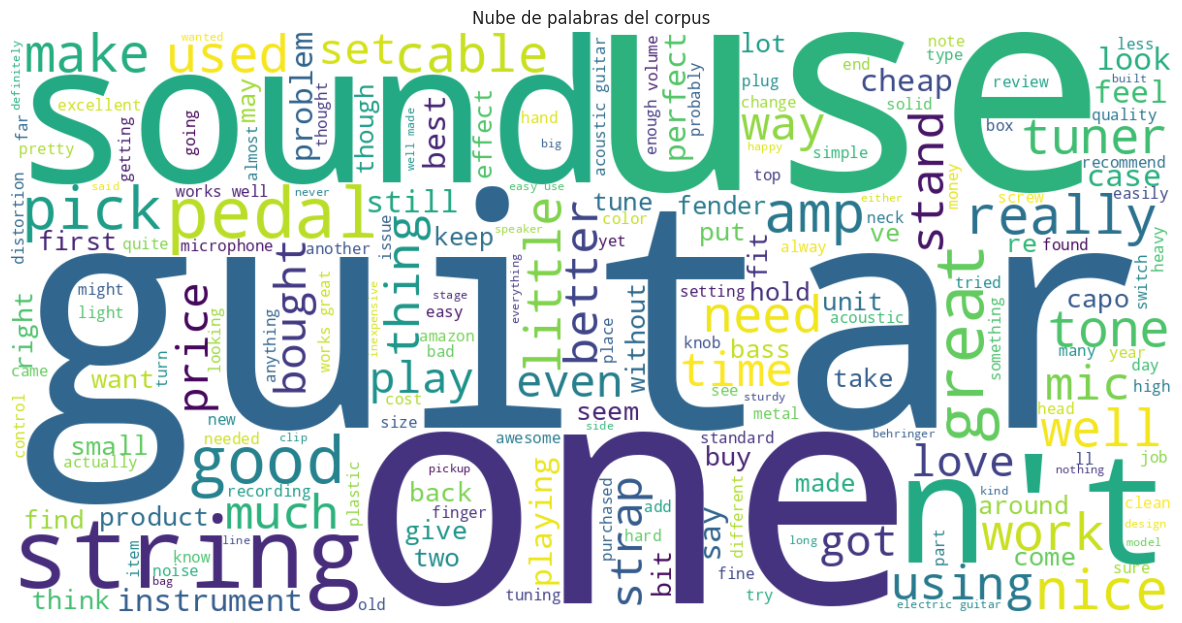

In [37]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(clean_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras del corpus")

plt.savefig(
    os.path.join(OUTPUT_PATH, "wordcloud.png"),
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [38]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.4 MB/s eta 0:00:00


In [39]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [40]:
# preparar frases limpias
sentences = []

for text in df_reviews["text"]:
    tokens = word_tokenize(str(text).lower())

    tokens_clean = [
        word for word in tokens
        if word not in stop_words
        and word not in string.punctuation
        and len(word) > 2
    ]

    sentences.append(tokens_clean)

sentences[:2]

[['good',
  'much',
  'write',
  'exactly',
  'supposed',
  'filters',
  'pop',
  'sounds',
  'recordings',
  'much',
  'crisp',
  'one',
  'lowest',
  'prices',
  'pop',
  'filters',
  'amazon',
  'might',
  'well',
  'buy',
  'honestly',
  'work',
  'despite',
  'pricing'],
 ['jake',
  'product',
  'exactly',
  'quite',
  'affordable.i',
  'realized',
  'double',
  'screened',
  'arrived',
  'even',
  'better',
  'expected.as',
  'added',
  'bonus',
  'one',
  'screens',
  'carries',
  'small',
  'hint',
  'smell',
  'old',
  'grape',
  'candy',
  'used',
  'buy',
  'reminiscent',
  'sake',
  'stop',
  'putting',
  'pop',
  'filter',
  'next',
  'nose',
  'smelling',
  'recording',
  'dif',
  'needed',
  'pop',
  'filter',
  'work',
  'well',
  'expensive',
  'ones',
  'may',
  'even',
  'come',
  'pleasing',
  'aroma',
  'like',
  'mine',
  'buy',
  'product']]

In [41]:
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1
)

In [42]:
w2v_model.wv.most_similar("guitar", topn=10)

[('violin', 0.7114359736442566),
 ('mandolin', 0.706903338432312),
 ('guitars', 0.7052783966064453),
 ('5-string', 0.6933468580245972),
 ('wonderfully', 0.6931881308555603),
 ('instrument', 0.6916007995605469),
 ('irish', 0.6909314393997192),
 ('mother', 0.6841440200805664),
 ('banjo', 0.6761243939399719),
 ('ukulele', 0.6759623885154724)]

In [43]:
w2v_model.wv.most_similar("sound", topn=10)

[('sounding', 0.7649003863334656),
 ('tone', 0.7369169592857361),
 ('sounds', 0.7357359528541565),
 ('warmth', 0.715241551399231),
 ('crisp', 0.7051162719726562),
 ('produce', 0.7037140130996704),
 ('tonal', 0.6933013200759888),
 ('crystal', 0.6875239610671997),
 ('ears', 0.6874212622642517),
 ('warm', 0.6796172857284546)]

In [44]:
w2v_model.wv.most_similar("quality", topn=10)

[('reasonable', 0.6941133737564087),
 ('grade', 0.6922096014022827),
 ('expectations', 0.6885467171669006),
 ('prices', 0.6840118169784546),
 ('reliability', 0.6665256023406982),
 ('priced', 0.6664628386497498),
 ('exceeded', 0.6645048260688782),
 ('craftsmanship', 0.6627340316772461),
 ('mogami', 0.6605833172798157),
 ('hosa', 0.6587233543395996)]

In [45]:
# Visualización en 2 dimensiones de algunos word embeddings calculados con word2Vec
words_to_plot = ["guitar", "sound", "quality", "price", "strings"]

similar_words = []

for word in words_to_plot:

    if word in w2v_model.wv:

        similar_words.append(word)

        similar_words += [
            w for w, score in w2v_model.wv.most_similar(word, topn=10)
        ]

# eliminar duplicados
similar_words = list(set(similar_words))

# obtener vectores
vectors = [w2v_model.wv[word] for word in similar_words]

In [46]:
pca = PCA(n_components=2)

vectors_2d = pca.fit_transform(vectors)

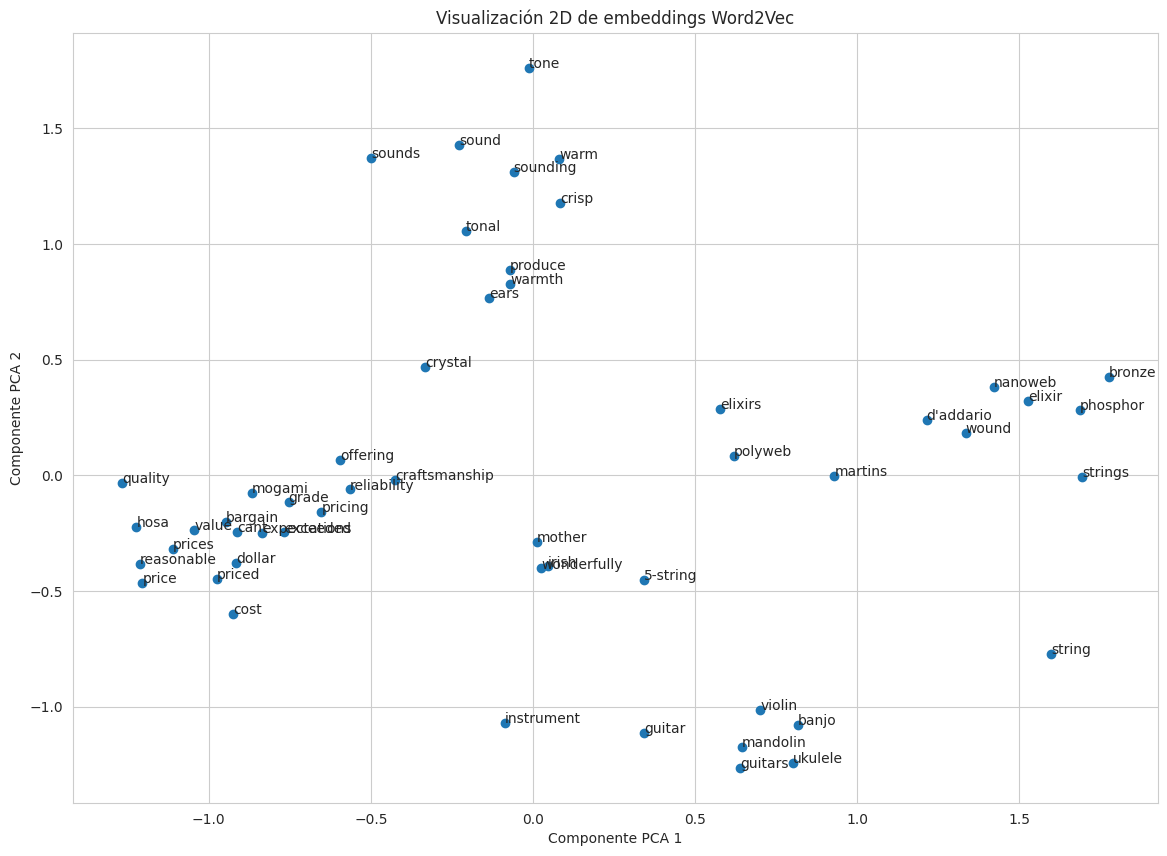

In [47]:
plt.figure(figsize=(14,10))

plt.scatter(
    vectors_2d[:,0],
    vectors_2d[:,1]
)

for i, word in enumerate(similar_words):

    plt.annotate(
        word,
        xy=(vectors_2d[i,0], vectors_2d[i,1])
    )

plt.title("Visualización 2D de embeddings Word2Vec")

plt.xlabel("Componente PCA 1")
plt.ylabel("Componente PCA 2")

plt.show()

palabras cercanas entre sí, formando pequeños clusters, ejemplo instrument,guitar,violin y en otro cluster temas de calidad etc está por relaciones semánticas

## Conclusiones de la exploración

El corpus utilizado corresponde a reviews de productos musicales de Amazon, con un total de 10.261 reseñas.

La distribución de estrellas muestra una concentración importante en calificaciones altas, especialmente en 5 estrellas. Al convertir el problema a clasificación binaria, se observa un desbalance de clases: aproximadamente el 88% de las reseñas son positivas y el 12% negativas.

El análisis inicial del vocabulario mostró más de 1.1 millones de palabras totales y una cardinalidad cercana a 31.000 palabras únicas. En las palabras y bigrams más frecuentes sin limpieza aparecen muchas stopwords y signos de puntuación, lo que evidencia la necesidad de una etapa posterior de preprocesamiento.

Después de aplicar una limpieza básica para la exploración, los bigrams más frecuentes muestran expresiones más interpretables como “works great”, “good quality”, “great product” y “sound great”, lo que confirma la presencia predominante de sentimiento positivo en el corpus.

La nube de palabras permite identificar términos frecuentes asociados al dominio de instrumentos musicales, como guitar, sound, strings, quality y product.

Finalmente, el modelo Word2Vec permitió identificar relaciones semánticas entre palabras. Por ejemplo, términos como quality se relacionan con value, premium y craftsmanship, lo que indica que los embeddings capturan información contextual útil del corpus.